<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/MachineLearning/ML_AprendizadoN%C3%A3oSupervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo: Aprendizado Não Supervisionado
O aprendizado é por descoberta. A IA não tem gabarito; ela busca padrões ocultos e semelhanças estruturais nos dados brutas (distância entre alturas).

## Aplicar conceitos de Machine Learning (ML), utilizando:
- **Aprendizado Não Supervisionado:** Uso de dados não rotulados. A IA não sabe quem é "Cavalo" ou "Outro"; ela recebe apenas as alturas.
- **Agrupamento (Clustering):** Técnica para descobrir grupos naturais nos dados. O objetivo é ver se a IA separa os animais grandes dos pequenos sozinha.
- **Engenharia de Features:** Extração da altura como variável de distância. A IA medirá quão perto uma altura está da outra para definir os grupos.
- **Análise de Descoberta:** Em vez de Acurácia, analisa-se a Inércia (união dos grupos), a posição dos Centroides e a visualização dos Clusters.

# Algoritmo de treino usado:
- Não Supervisionado = K-Means: Um algoritmo "organizador" que não sabe o nome das coisas, mas sabe separar o que é parecido por meio da distância física entre os números.

In [1]:
# descompacta pasta
!unzip -q cavalos.zip -d /content/cavalos_data
!unzip -q outros.zip -d /content/outros_data

In [2]:
# coletar dados
# extraindo frames dos videos (videos e apenas uma pilha de imagens)
import cv2
import os

# Configurar onde estão os vídeos e onde salvar as fotos
pasta_videos = '/content/cavalos_data/cavalos'
pasta_destino = '/content/dataset/cavalos'
os.makedirs(pasta_destino, exist_ok=True)

# Lista todos os arquivos da pasta
arquivos = os.listdir(pasta_videos)

for nome_arquivo in arquivos:
    # Caminho completo do vídeo
    caminho_completo = os.path.join(pasta_videos, nome_arquivo)

    # Abre o vídeo
    video = cv2.VideoCapture(caminho_completo)

    # Tira o primeiro frame (sucesso = True/False, imagem = os pixels)
    sucesso, imagem = video.read()

    if sucesso:
        #  Salva a imagem com um nome novo
        nome_foto = nome_arquivo + ".jpg"
        caminho_salvamento = os.path.join(pasta_destino, nome_foto)
        cv2.imwrite(caminho_salvamento, imagem)
        print(f"Sucesso: {nome_foto} extraído!")

    video.release()

Sucesso: 8.mp4.jpg extraído!
Sucesso: 7.mp4.jpg extraído!
Sucesso: 1.mp4.jpg extraído!
Sucesso: 2.mp4.jpg extraído!
Sucesso: 9.mp4.jpg extraído!
Sucesso: 6.mp4.jpg extraído!
Sucesso: 3.mp4.jpg extraído!
Sucesso: 5.mp4.jpg extraído!
Sucesso: 4.mp4.jpg extraído!
Sucesso: 10.mp4.jpg extraído!


In [3]:
# escolha de features - altura_estimada
# Coluna 1: Altura Estimada (em metros)

# matriz de atributos
feacture = [
  # cavalos
  [1.80], [1.80], [1.80], [1.70], [1.80], [1.80], [1.80], [1.80], [1.70], [1.80],
  # outros
  [1.60], [1.60], [1.20], [1.00], [1.60], [1.60], [0.60], [0.50], [0.50], [0.60]
]

# esse GABARITO, agora não é enviado ao modelo no NÃO supervisionado
# resposta binaria para classificação 1 cavalo / 0 outros
# resposta_classificacao = [1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0]


### Por que NÃO usamos Loop e Épocas no Aprendizado Não Supervisionado (K-Means)?

No aprendizado não supervisionado (Clustering), o modelo aprende por **Geometria e Distância**.

1. **Sem Alvo:** O modelo não tem gabarito. Ele não sabe o que é um "cavalo".
2. **Cálculo Direto:** Algoritmos como o K-Means funcionam medindo a distância entre os pontos. Ele olha para as alturas e calcula matematicamente onde estão os centros dos grupos (centroides).
3. **Convergência Rápida:** Diferente de uma rede neural que precisa de ajustes minúsculos, o K-Means consegue encontrar o equilíbrio dos grupos em pouquíssimas iterações internas de cálculo de média.
4. **Sem Otimizador:** Como não há um "erro" em relação a uma resposta correta, não faz sentido "girar parafusos" para diminuir o erro. O algoritmo apenas agrupa o que é parecido.

**Resumo:** O processo é baseado em cálculos de distância média, o que o torna quase instantâneo e dispensa o loop de treinamento exaustivo.

In [7]:
# treinar classificador
# escolher algoritmo
# Em vez de um neurônio do PyTorch, usamos o K-Means (o rei do Não Supervisionado)
import torch
from sklearn.cluster import KMeans

# PyTorch usa tensores(matrizes para numeros) e não listas
alturasPossiveis = torch.tensor(feacture, dtype=torch.float32)

# CONVERSÃO NECESSÁRIA: O KMeans prefere arrays NumPy
# Usamos .numpy() para que a biblioteca sklearn consiga ler os dados
alturas_np = alturasPossiveis.numpy()

# Criao modelo de Agrupamento
# Pedimos para ele encontrar 2 grupos (n_clusters=2)
modelo_agrupamento = KMeans(n_clusters=3, n_init=10)

# O "Treino" agora se chama FIT (Encaixar)
# A IA vai olhar as alturas e definir onde ficam os centros dos grupos
modelo_agrupamento.fit(alturasPossiveis)

# As Previsões (Labels que a IA criou sozinha)
grupos_descobertos = modelo_agrupamento.labels_

print("Agrupamento finalizado!")
print(f"Grupos criados pela IA: {grupos_descobertos}")



Agrupamento finalizado!
Grupos criados pela IA: [0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 1 1 1 1]


In [8]:
# Relatório de Métricas para Aprendizado Não Supervisionado (Clustering)
from sklearn.metrics import silhouette_score

# INÉRCIA (Soma dos quadrados intra-cluster)
# Mede o quão "compactos" são os grupos.
# Quanto menor a inércia, mais próximos os pontos estão do centro do seu grupo.
inercia = modelo_agrupamento.inertia_

# COEFICIENTE DE SILHUETA
# Mede quão bem um ponto se encaixa no seu grupo em comparação aos outros grupos.
# Varia de -1 a 1:
# Próximo de 1: O grupo está muito bem separado dos outros.
# Próximo de 0: Os grupos estão encostados ou sobrepostos.
# Próximo de -1: O ponto provavelmente foi colocado no grupo errado.
silhueta = silhouette_score(alturasPossiveis, modelo_agrupamento.labels_)

print(f"--- MÉTRICAS DE DESCOBERTA (K-MEANS) ---")
print(f"Inércia: {inercia:.2f}")
print(f"Coeficiente de Silhueta: {silhueta:.2f}")

# CENTROIDES
# São os "representantes" de cada grupo (a altura média que define o grupo)
centros = modelo_agrupamento.cluster_centers_
print(f"\nCentros dos grupos (Alturas médias):")
for i, centro in enumerate(centros):
    print(f"Grupo {i}: {centro[0]:.2f}m")

--- MÉTRICAS DE DESCOBERTA (K-MEANS) ---
Inércia: 0.14
Coeficiente de Silhueta: 0.82

Centros dos grupos (Alturas médias):
Grupo 0: 1.73m
Grupo 1: 0.55m
Grupo 2: 1.10m


# Gráfico de Loss e Fronteira de Decisão vs Gráfico de Clusters

- **O gráfico de Loss não existe no Aprendizado Não Supervisionado (K-Means):** Isso acontece porque o gráfico de Loss mostra a evolução do erro ao longo do tempo (épocas). Como o K-Means não tem épocas e não aprende por tentativa e erro baseado em um gabarito, não há uma "curva" para desenhar. Ele calcula as médias e posições de forma direta.

- **Substituição pela Visualização de Clusters:** No lugar do Loss e da Fronteira de Decisão, utilizamos o **Gráfico de Clusters (Agrupamento)**.
    - Enquanto a Fronteira de Decisão é uma linha imposta pelo "professor" (gabarito), o Gráfico de Clusters mostra como a IA descobriu padrões sozinha.
    - A separação entre os grupos é definida pelos **Centroides** (os centros de cada grupo). A "fronteira" aqui é o ponto médio de distância entre esses centros descobertos pela IA.

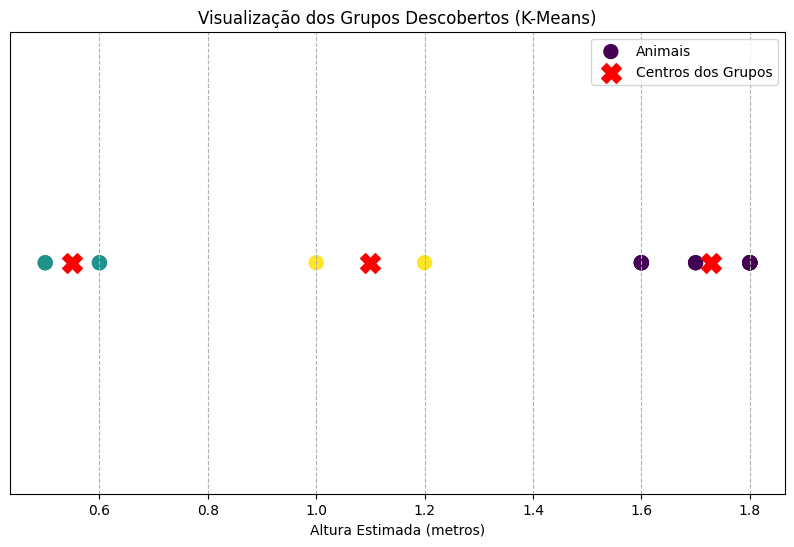

In [11]:
# Gráfico de Clusters (Substitui o Gráfico de Loss)
import matplotlib.pyplot as plt

# Pegamos as alturas e as predições (os grupos que a IA criou)
predicoes = modelo_agrupamento.labels_
centros = modelo_agrupamento.cluster_centers_

plt.figure(figsize=(10, 6))

# Desenha os pontos coloridos por grupo
plt.scatter(alturasPossiveis, [0] * len(alturasPossiveis), c=predicoes, s=100, cmap='viridis', label='Animais')

# Desenha os Centroides (o "coração" de cada grupo)
plt.scatter(centros, [0, 0, 0], c='red', marker='X', s=200, label='Centros dos Grupos')

plt.title('Visualização dos Grupos Descobertos (K-Means)')
plt.xlabel('Altura Estimada (metros)')
plt.yticks([]) # Esconde o eixo Y pois só temos a altura
plt.legend()
plt.grid(True, axis='x', linestyle='--')
plt.show()